# 数值方程模型的求解方法

在高等数学中，介绍了一些特殊类型微分方程的解析解法，但是大量的微分方程由千过千复杂往往难以求出解析解．此时可以应用数值解法，求得微分方程的近似解。

## 1. 微分方程的数值解


#### 显示欧拉（左矩形公式）和梯形公式对比

A

$\bodysymbols{A}$

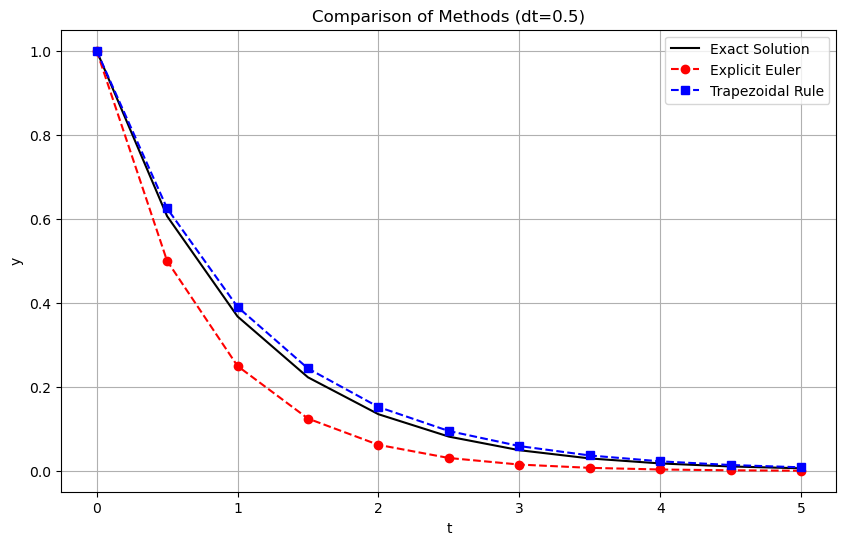

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
t_end = 5.0
dt = 0.5
steps = int(t_end / dt)
t = np.linspace(0, t_end, steps+1)

# 解析解
y_exact = np.exp(-t)

# 显式欧拉 (左矩形)
y_euler = np.zeros(steps+1)
y_euler[0] = 1.0
for i in range(steps):
    y_euler[i+1] = y_euler[i] - y_euler[i] * dt

# 梯形法 (需解方程，此处用迭代法)
y_trap = np.zeros(steps+1)
y_trap[0] = 1.0
for i in range(steps):
    # 预测步 (用欧拉法)
    y_pred = y_trap[i] - y_trap[i] * dt
    # 校正步 (梯形公式)
    y_trap[i+1] = y_trap[i] + 0.5 * dt * (
        -y_trap[i] - y_pred
    )

# 绘图比较
plt.figure(figsize=(10, 6))
plt.plot(t, y_exact, 'k-', label="Exact Solution")
plt.plot(t, y_euler, 'ro--', label="Explicit Euler")
plt.plot(t, y_trap, 'bs--', label="Trapezoidal Rule")
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.title(f"Comparison of Methods (dt={dt})")
plt.grid(True)
plt.show()

## 2. 用 Python 求解微分方程

#### （1）符号解法（第 3 章）

求下微分列方程的特解
$$
\left\{
\begin{aligned}
& \frac{d^2 y}{dx^2} + 2 \frac{dy}{dx} + 2y = 0, \\
& y(0) = 0,\quad y'(0) = 1.
\end{aligned}
\right.
$$

In [ ]:
from sympy.abc import x
from sympy import Function, dsolve, diff, simplify
y = Function('y')
eq = diff(y(x), x, 2) + 2 * diff(y(x), x) + 2 * y(x)  # 定义微分方程
con = {y(0): 0, y(x).diff(x).subs(x, 0): 1}  # 初始条件
y = dsolve(eq, y(x), ics=con)  # 求解微分方程
print(f"微分方程的符号解为：{simplify(y.rhs)}")  # rhs 提取右侧表达式

微分方程的特解为：exp(-x)*sin(x)


$$
\left\{
\begin{aligned}
& \frac{d^2 y}{dx^2} + 2 \frac{dy}{dx} + 2y = sin\,x, \\
& y(0) = 0,\quad y'(0) = 1.
\end{aligned}
\right.
$$

In [17]:
from sympy.abc import x
from sympy import Function, dsolve, diff, sin, simplify
y = Function('y')
eq = diff(y(x), x, 2) + 2 * diff(y(x), x) + 2 * y(x) - sin(x)  # 定义微分方程
con = {y(0): 0, y(x).diff(x).subs(x, 0): 1}  # 初始条件
y = dsolve(eq, ics=con)  # 求解微分方程
print(f"微分方程的符号解为：{simplify(y.rhs)}")  # rhs 提取右侧表达式 

微分方程的符号解为：((sin(x) - 2*cos(x))*exp(x) + 6*sin(x) + 2*cos(x))*exp(-x)/5


求下列微分方程组的解

$$
\left\{
\begin{aligned}
& \frac{dx_1}{dt} = 2x_1 - 3x_2 + 3x_3,\quad x_1(0) = 1, \\
& \frac{dx_2}{dt} = 4x_1 - 5x_2 + 3x_3,\quad x_2(0) = 2, \\
& \frac{dx_3}{dt} = 4x_1 - 4x_2 + 2x_3,\quad x_3(0) = 3.
\end{aligned}
\right.
$$

In [24]:
import sympy as sp
t = sp.symbols('t')
x1, x2, x3 = sp.symbols('x1 x2 x3', cls=sp.Function)
eq = [x1(t).diff(t) - 2*x1(t) + 3*x2(t) - 3*x3(t),
      x2(t).diff(t) - 4*x1(t) + 5*x2(t) - 3*x3(t),
      x3(t).diff(t) - 4*x1(t) + 4*x2(t) - 2*x3(t)]
con = {x1(0): 1, x2(0): 2, x3(0): 3}  # 初始条件
sol = sp.dsolve(eq, ics=con)  # 求解微分方程组
print(sol)

[Eq(x1(t), 2*exp(2*t) - exp(-t)), Eq(x2(t), 2*exp(2*t) - exp(-t) + exp(-2*t)), Eq(x3(t), 2*exp(2*t) + exp(-2*t))]


In [ ]:
# 上述代码的简洁形式(矩阵表达式)
import sympy as sp
t = sp.symbols('t')
x1, x2, x3 = sp.symbols('x1:4', cls=sp.Function)
x = sp.Matrix([x1(t), x2(t), x3(t)])
A = sp.Matrix([[2, -3, 3], [4, -5, 3], [4, -4, 2]])
eq = x.diff(t) - A * x
con = {x1(0): 1, x2(0): 2, x3(0): 3}  # 初始条件
sol = sp.dsolve(eq, ics=con)  # 求解微分方程组
print(sol)

[Eq(x1(t), 2*exp(2*t) - exp(-t)), Eq(x2(t), 2*exp(2*t) - exp(-t) + exp(-2*t)), Eq(x3(t), 2*exp(2*t) + exp(-2*t))]


#### （2）数值解法

Python 对常微分方程的数值求解是基于一阶方程进行的， 高阶微分方程必须
化成一阶方程组， 通常采用龙格－库塔方法． scipy.integrate 模块的 odeint 函数求常
微分方程的数值解，其基本调用格式为

#### sol = odeint(func, y0, t)(ordinary differential equation integration常微分方程积分)

| 参数/返回值 | 含义                                                                                                             |
| ------ | -------------------------------------------------------------------------------------------------------------- |
| `func` | 定义微分方程的函数或可调用对象（函数句柄 / 匿名函数）                                                                                   |
| `y0`   | 初始条件序列（长度为 n 的数组或列表）                                                                                           |
| `t`    | 自变量的离散取值序列；**第一个元素必须是初始时刻**                                                                                    |
| `sol`  | 数值解矩阵；<br>• 行数 = `len(t)`，对应每个时间点；<br>• 列数 = n（方程组中未知函数的个数）；<br>• 第 `i` 列（`i = 1,2,…,n`）给出第 `i` 个函数在所有时间点上的数值解 |


求微分方程
$$
\left\{
\begin{aligned}
& y' = -2y + x^2 + 2x, \\
& y(1) = 2.
\end{aligned}
\right.
$$

在$1 \leq x \leq 10$步长间隔为$0.5$点上的数值解.

In [3]:
from scipy.integrate import odeint
from numpy import arange
dy = lambda y, x: -2 * y + x**2 + 2 * x
x = arange(1, 10.5, 0.5)
sol = odeint(dy, 2, x)  # 初始值为2
print(f"x=()\n对应的数值解\n y={(x, sol.T)}")

x=()
对应的数值解
 y=(array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
        6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ]), array([[ 2.        ,  2.08484933,  2.9191691 ,  4.18723381,  5.77289452,
         7.63342241,  9.75309843, 12.12613985, 14.75041934, 17.62515427,
        20.75005673, 24.12502089, 27.7500077 , 31.62500278, 35.75000104,
        40.1250004 , 44.75000015, 49.62500006, 54.75000002]]))


解 引进$y_1 = y$, $y_2 = y'$，则可以把原来的二阶微分方程化为如下一阶微分方程组：
$$
\left\{
\begin{aligned}
& y_1' = y_2,\quad y_1(0) = 0, \\
& y_2' = -2y_1 - 2y_2,\quad y_2(0) = 1.
\end{aligned}
\right.
$$

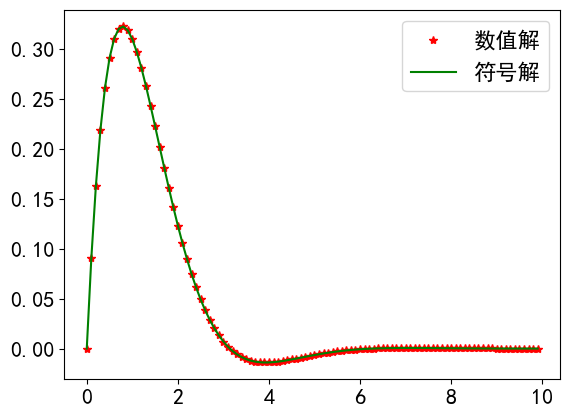

In [ ]:
import numpy as np
from scipy.integrate import odeint
from sympy.abc import t
import matplotlib.pyplot as plt

# 定义微分方程
def Pfun(y, x):
    y1, y2 = y
    return np.array([y2, -2 * y1 - 2 * y2])  # y2即y1'， -2y1 - 2y2即y2'

x = np.arange(0, 10, 0.1)  # 创建时间点,自变量取值
soll = odeint(Pfun, [0, 1], x)  # 初始条件为 [0, 1],求数值解(y1(0)=0, y2(0)=1)

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['font.size'] = 16  # 设置字体大小

plt.plot(x, soll[:, 0], 'r*', label='数值解')
plt.plot(x, np.exp(-x) * np.sin(x), 'g', label='符号解')
plt.legend()
plt.savefig('符号解和数值解对比图.png', dpi=500)
plt.show()

Lorenz 模型的混沌效应

Lorenz 模型是由美国气象学家 Lorenz 在研究大气运动时，通过简化对流模型只保留 3 个变量提出的一个完全确定性的一阶自治常微分方程组 (不显含时间变量)，其方程为

$$
\left\{
\begin{aligned}
& \dot{x} = \sigma (y - x), \\
& \dot{y} = \rho x - y - x z, \\
& \dot{z} = x y - \beta z.
\end{aligned}
\right.
$$

其中，参数$\sigma$为 Prandtl 数，$\rho$为 Rayleigh 数，$\beta$为方向比. Lorenz 模型如今已经成为混沌领域的经典模型，第一个混沌吸引子 —— Lorenz 吸引子也是在这个系统中被发现的. 系统中三个参数的选择对系统会不会进入混沌状态起着重要的作用. 

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def Lorenz(state, t):
    sigma = 10
    rho = 28
    beta = 8 / 3
    x, y, z = state
    return np.array([
        sigma * (y - x),
        rho * x - y - x * z,
        x * y - beta * z
    ])
    
t = np.linspace(0, 50, 10000)  # 时间范围,自变量
sol1 = odeint(Lorenz, [0, 1, 0], t)  # 初始条件为 [0, 1, 0]
sol2 = odeint(Lorenz, [0, 1.0001, 0], t)  # 初始条件为 [0, 1.0001, 0]
delta = sol1 - sol2  # 计算两个解的偏差

plt.rcParams['font.size'] = 12  # 设置字体大小
plt.rcParams['text.usetex'] = True  # 使用 LaTeX 渲染文本
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(sol1[:, 0], sol1[:, 1], sol1[:, 2], 'r', linewidth=0.5)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_zlabel('$z$')
ax1.set_title('Lorenz system trajectory (initial value: [0, 1, 0])')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(delta[:, 0], delta[:, 1], delta[:, 2], 'g', linewidth=0.5)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_zlabel('$z$')
ax2.set_title('Evolution of initial value deviation (deltay₀ = 0.0001)')

plt.tight_layout()  # 自动调整子图间距
plt.savefig("Lorenz_system.png", dpi=500, bbox_inches='tight')
plt.show()

# 打印数量太大
print(f"sol1={sol1}", '\n\n', f"sol1-sol2={sol1-sol2}")

# 摘要输出代替完整数组
# print("初始条件1终点:", sol1[-1].round(2))
# print("初始条件2终点:", sol2[-1].round(2))
# print("终点偏差:", (sol1[-1]-sol2[-1]).round(4))

左图 给出了 Lorenz 模型在$\sigma = 10$, $\rho = 28$, $\beta = 8/3$时系统的三维演化轨迹. 由左图 可见，经过长时间运行后，系统只在三维空间的一个有限区域内运动，即在三维相空间里的测度为零. 左图 显示出我们经常听到的“蝴蝶效应”. 图 8.2(b) 给出了系统从两个靠得很近的初值出发 (相差仅 0.0001) 后，解的偏差演化曲线. 随着时间的增大，可以看到两个解的差异越来越大，这正是动力学系统对初值敏感性的直观表现，由此可断定此系统的这种状态为混沌态. 混沌运动是确定性系统中存在随机性，它的运动轨道对初始条件极端敏感.


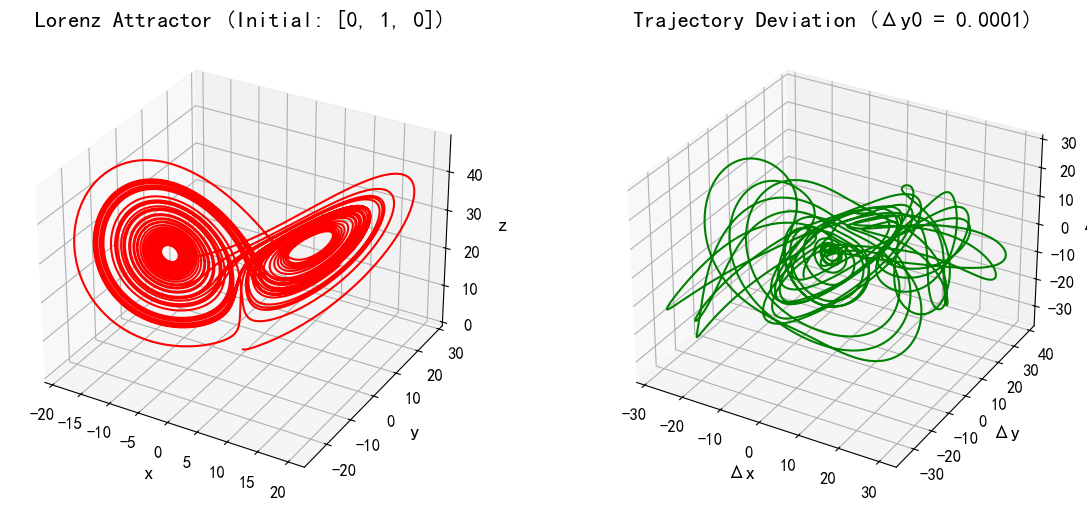

sol1=
[[0.00000000e+00 1.00000000e+00 0.00000000e+00]
 [4.87093468e-02 9.98445554e-01 1.22091260e-04]
 [9.51319373e-02 1.00353668e+00 4.79098346e-04]
 ...
 [9.46008897e+00 1.60052644e+01 1.69318089e+01]
 [9.79015646e+00 1.64436356e+01 1.74833538e+01]
 [1.01252090e+01 1.68693179e+01 1.80757858e+01]] 

 sol1-sol2=
[[ 0.00000000e+00 -1.00000000e-04  0.00000000e+00]
 [-4.87093611e-06 -9.98445522e-05 -2.44193237e-08]
 [-9.51319399e-06 -1.00353645e-04 -9.58244255e-08]
 ...
 [-4.41456802e+00 -6.50312197e+00 -5.94696786e+00]
 [-4.51092891e+00 -6.26740909e+00 -6.67525340e+00]
 [-4.58931413e+00 -5.95859104e+00 -7.40445020e+00]]


In [48]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def Lorenz(state, t):
    sigma = 10
    rho = 28
    beta = 8 / 3
    x, y, z = state
    return np.array([
        sigma * (y - x),
        rho * x - y - x * z,
        x * y - beta * z
    ])
    
t = np.linspace(0, 50, 10000)  # 时间范围,自变量
sol1 = odeint(Lorenz, [0, 1, 0], t)  # 初始条件为 [0, 1, 0]
sol2 = odeint(Lorenz, [0, 1.0001, 0], t)  # 初始条件为 [0, 1.0001, 0]

plt.rcParams['font.size'] = 12  # 减小字体大小避免重叠

fig = plt.figure(figsize=(14, 6))

# 第一幅图：Lorenz 系统轨迹
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(sol1[:, 0], sol1[:, 1], sol1[:, 2], 'r')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Lorenz Attractor (Initial: [0, 1, 0])')

# 第二幅图：两个解的偏差
ax2 = fig.add_subplot(122, projection='3d')
delta = sol1 - sol2
ax2.plot(delta[:, 0], delta[:, 1], delta[:, 2], 'g')
ax2.set_xlabel('Δx')
ax2.set_ylabel('Δy')
ax2.set_zlabel('Δz')
# ax2.view_init(elev=15, azim=30)  # 优化视角,否则看不到Δz，但是视图会发生翻转
ax2.set_title('Trajectory Deviation (Δy0 = 0.0001)')

# plt.tight_layout()  # 防止标签重叠
plt.savefig("Lorenz_system.png", dpi=500, bbox_inches='tight')
plt.show()

print(f"sol1=\n{sol1}", '\n\n', f"sol1-sol2=\n{delta}")

左图 给出了 Lorenz 模型在 $\sigma = 10, \rho = 28, \beta ＝ 8/3$ 时系统的三维演化轨迹．由左图 可见，经过长时间运行后，系统只在三维空间的一个有限区域内运动，即在三维相空间里的测度为零．左图 显示出我们经常听到的＂蝴蝶效应＂．右图给出了系统从两个靠得很近的初值出发（相差仅$0.0001$）后，解的偏差演化曲线．随着时间的增大，可以看到两个解的差异越来越大，这正是动力学系统对初值敏感性的直观表现，由此可断定此系统的这种状态为混沌态．混沌运动是确定性系统中存在随机性，它的运动轨道对初始条件极端敏感．